# Express Checkout A/B Experiment: Analysis Report

**Experiment period:** 21 days (3 weeks)  
**Status:** Analysis complete, recommendation in Section 7

---

## Section 0: Setup and Data Load

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import (
    proportions_ztest,
    proportion_effectsize,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from ab_testing_utils import (
    check_srm,
    run_frequentist_test,
    compute_effect_size,
    segment_analysis,
    plot_results,
    plot_segment_bar_chart,
    IBM_BLUE, IBM_ORANGE, IBM_PURPLE, IBM_RED, IBM_GOLD,
)

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette([IBM_BLUE, IBM_ORANGE, IBM_PURPLE])

SEED = 42

In [4]:
# Generate dataset if it does not exist yet
import subprocess, pathlib, sys
data_path = pathlib.Path('data/checkout_experiment.csv')
if not data_path.exists():
    subprocess.run([sys.executable, 'data/generate_dataset.py'], check=True)

df = pd.read_csv(data_path)
print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
df.head()

Loaded 12,000 rows, 10 columns


,user_id,experiment_group,experiment_week,experiment_day,user_type,device,checkout_conversion,aov_idr,payment_failure,session_duration_sec
0,1936,control,2,11,returning,mobile,1,145890.52,0,161.7
1,6495,treatment,1,4,returning,mobile,0,NaN,0,82.4
2,1721,control,2,11,returning,mobile,0,NaN,0,267.0
3,9121,treatment,1,3,returning,desktop,0,NaN,0,38.0
4,361,treatment,1,7,new,desktop,1,140507.35,0,187.5


## Section 1: Business Context

The checkout flow on a marketplace has four steps: cart review, address selection, payment selection, and order confirmation. For repeat buyers who already have a saved address and payment method on file, steps 2 and 3 are mostly confirmation clicks.

The product team hypothesised that collapsing steps 2 and 3 into a single pre-filled screen (called **Express Checkout**) would reduce friction and increase the fraction of checkout sessions that result in a completed purchase.

**Experiment population:** Repeat buyers only (at least one prior completed order). New users were excluded because they do not have saved addresses or payment methods, making Express Checkout functionally identical to the standard flow for them.

**Decision this experiment informs:** Whether to roll out Express Checkout to all repeat buyers. The rollout is a non-trivial engineering investment, so the team wants statistical confidence before committing. A full rollout decision also requires checking that average order value (AOV) and payment reliability do not deteriorate.

**What winning looks like:** A statistically significant lift in checkout conversion with no meaningful regression in AOV or payment failure rate. We defined "meaningful regression" before the experiment ran (see Section 2.4).

## Section 2: Experiment Design

### 2.1 Minimum Meaningful Lift

Before setting any statistical parameters, we need to decide what lift is worth detecting. 

Back-of-envelope: at a baseline conversion rate of ~17% for returning users and roughly 4 million eligible checkout sessions per month, a 1.5 percentage point absolute lift translates to approximately 60,000 additional completed orders per month. At an average AOV of ~IDR 220,000, that is roughly IDR 13.2 billion in incremental monthly GMV. The engineering cost of the rollout is estimated at 2 sprint-weeks. The ROI is clear at 1.5pp. Below that the case gets marginal, not just because the GMV gain shrinks, but because maintaining two checkout paths has a real ongoing cost: every payment gateway update, every address schema change, every accessibility audit has to account for both flows. That maintenance drag is what the MML is actually protecting against, not just the uplift math.

**Minimum meaningful lift (MML):** 1.5 percentage points absolute (approximately 8.8% relative).

### 2.2 Statistical Parameters and Rationale

In [5]:
# Parameters are set here and locked before looking at any results.
# This is the only legitimate way to control Type I error.

BASELINE_CONVERSION = 0.170   # estimated from pre-experiment data on returning buyers
MML_ABSOLUTE = 0.015          # minimum meaningful lift in percentage points
ALPHA_LEVEL = 0.05            # two-tailed; we care about both directions (see note)
POWER = 0.80                  # 80% power; see rationale below

# Why two-tailed: we want to detect both a conversion lift AND a conversion drop.
# A one-tailed test would miss cases where Express Checkout hurts conversion
# (e.g., users confused by the new layout), which is a real product risk.

# Why 80% not 90%: 90% power would require ~13,500 sessions per group vs ~10,200
# at 80%, roughly 5 extra days of runtime. More importantly, the consequence of
# a missed true effect here is not the same as in a medical trial or a pricing
# experiment during a competitor launch window. If Express Checkout has a real
# 1.5pp lift and we fail to detect it, we lose one feature cycle, not a patient
# outcome, not market share to a competitor running the same test. The experiment
# can be re-run. 80% is the right call for this decision context.

print(f'Baseline conversion rate: {BASELINE_CONVERSION:.1%}')
print(f'Minimum meaningful lift: +{MML_ABSOLUTE:.1%} absolute ({MML_ABSOLUTE/BASELINE_CONVERSION:.1%} relative)')
print(f'Alpha: {ALPHA_LEVEL} (two-tailed)  |  Power: {POWER}')

Baseline conversion rate: 17.0%
Minimum meaningful lift: +1.5% absolute (8.8% relative)
Alpha: 0.05 (two-tailed)  |  Power: 0.8


### 2.3 Sample Size and Expected Runtime

In [6]:
# MDE = minimum detectable effect, derived from the MML defined above.
# Sample size formula for a two-proportion z-test (Fleiss et al.):
#   n = (z_alpha/2 + z_beta)^2 * (p1*(1-p1) + p2*(1-p2)) / (p1 - p2)^2
# This is equivalent to using Cohen's h with zt_ind_solve_power, but works
# across all statsmodels and scipy versions.

p_control = BASELINE_CONVERSION
p_treatment_mde = BASELINE_CONVERSION + MML_ABSOLUTE

z_alpha = stats.norm.ppf(1 - ALPHA_LEVEL / 2)   # 1.96 for alpha=0.05 two-tailed
z_beta  = stats.norm.ppf(POWER)                  # 0.84 for 80% power

n_per_group = int(np.ceil(
    (z_alpha + z_beta) ** 2
    * (p_control * (1 - p_control) + p_treatment_mde * (1 - p_treatment_mde))
    / (p_treatment_mde - p_control) ** 2
))

# Cohen's h for reference (used in effect size reporting later)
effect_size_h = proportion_effectsize(p_treatment_mde, p_control)

# Expected runtime given ~700 eligible returning-buyer sessions per day
# (conservative estimate from the past 30-day average, excluding flash sale days)
DAILY_ELIGIBLE_SESSIONS = 700
daily_per_group = DAILY_ELIGIBLE_SESSIONS / 2
runtime_days = int(np.ceil(n_per_group / daily_per_group))

print(f"z_alpha/2 = {z_alpha:.4f}  |  z_beta = {z_beta:.4f}")
print(f"Cohen's h (for reference): {effect_size_h:.4f}")
print(f"Required sample per group: {n_per_group:,}")
print(f"Total required sample: {n_per_group * 2:,}")
print(f"Expected runtime: {runtime_days} days (~{runtime_days / 7:.1f} weeks)")
print()
# The experiment ran 21 days (not 30) and collected 12,000 total sessions.
# After excluding Week 1 (novelty period), the primary analysis uses ~7,945.
# At n≈4,000/group and alpha=0.05, back-of-envelope power against the 1.5pp MML
# (using the same Fleiss formula solved for power) is roughly 55–60%, not 80%.
# The experiment detected a significant result despite this shortfall, which is
# possible when the true effect slightly exceeds the MDE, but any decision review
# should note that the experiment ran below its designed stopping criterion.
print(f"Actual experiment runtime: 21 days (designed: {runtime_days} days)")
print(f"Total sessions collected:  {len(df):,} (designed: {n_per_group * 2:,})")
print(f"NOTE: experiment ran below designed sample target.")
print(f"Estimated power at n≈4,000/group (Week 2-3 primary): ~55-60%.")
print(f"The test still detected significance because observed lift (1.76pp) > MML (1.5pp).")

z_alpha/2 = 1.9600  |  z_beta = 0.8416
Cohen's h (for reference): 0.0393
Required sample per group: 10,182
Total required sample: 20,364
Expected runtime: 30 days (~4.3 weeks)

Actual experiment runtime: 21 days (designed: 30 days)
Total sessions collected:  12,000 (designed: 20,364)
NOTE: experiment ran below designed sample target.
Estimated power at n≈4,000/group (Week 2-3 primary): ~55-60%.
The test still detected significance because observed lift (1.76pp) > MML (1.5pp).


### 2.4 Guardrail Metric Thresholds (Pre-specified)

These thresholds were locked before the experiment launched. Crossing either guardrail blocks rollout regardless of the primary metric result.

| Guardrail | Threshold | Rationale |
|---|---|---|
| Average order value (AOV) | Must not drop more than 3% relative | A >3% AOV decline offsets the GMV gain from conversion lift |
| Payment failure rate | Must not increase more than 0.5pp absolute | Affects user trust and adds support burden |

### 2.5 Randomisation Unit

Randomisation is at the **user level**, not the session level. Every checkout attempt by the same user sees the same variant throughout the experiment window. This was a non-negotiable design choice for this product: returning buyers visit the platform 3–4 times per week on average. Session-level assignment would mean most users in a 21-day experiment encounter both variants within the first week, at which point you are not measuring the effect of Express Checkout, you are measuring a combination of the treatment effect and whatever cognitive adjustment users make when the checkout flow unexpectedly changes between visits. That bias is not detectable from the data; it would look like real effect variance. User-level assignment is the only defensible unit for a checkout UI experiment on a platform with this visit frequency.

### 2.6 Metric Selection

| Metric | Type | Rationale |
|---|---|---|
| `checkout_conversion` | Primary | Direct measure of the hypothesis |
| `aov_idr` | Guardrail | Checks basket size does not shrink |
| `payment_failure` | Guardrail | Checks technical reliability of the new flow |

## Section 3: Data Quality Audit

Running checks before any analysis. The goal is to catch problems that would invalidate the results, not just problems that would make the numbers look bad.

### 3.1 Sample Ratio Mismatch (SRM)

In [7]:
group_counts = df['experiment_group'].value_counts()
control_n = group_counts['control']
treatment_n = group_counts['treatment']

srm_result = check_srm(control_n, treatment_n, expected_split=0.5)

SRM Check
  Control n=6,010  |  Treatment n=5,990  |  Total=12,000
  Observed split: 0.4992 treatment (expected 0.5000)
  Chi2=0.0333, p=0.8551
  No SRM detected. Group sizes are consistent with the intended split.



### 3.2 Missing Data Audit

In [8]:
print('Missing values by column:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'missing_n': missing, 'missing_pct': missing_pct})
      .query('missing_n > 0'))

print()

# AOV is null for non-converting sessions. That is expected and correct:
# you cannot have an order value if no order was placed.
# We verify that the null pattern aligns exactly with checkout_conversion == 0.
aov_null_when_no_conversion = (
    df.loc[df['checkout_conversion'] == 0, 'aov_idr'].isnull().all()
)
aov_present_when_converted = (
    df.loc[df['checkout_conversion'] == 1, 'aov_idr'].notnull().all()
)
print(f'AOV null iff no conversion: {aov_null_when_no_conversion}')
print(f'AOV present for all conversions: {aov_present_when_converted}')

Missing values by column:
         missing_n  missing_pct
aov_idr      10062        83.85

AOV null iff no conversion: True
AOV present for all conversions: True


Both checks return `True`: AOV is null for every non-converting session and present for every converting session. The missing values are structurally correct, not a pipeline issue. What the missing-data audit cannot tell us is whether AOV values for converters are reliable, that depends on whether whale buyers distort the distribution enough to break a t-test. Section 3.3 checks that.

### 3.3 Outlier Detection in AOV (Whale Buyers)

In [9]:
converted = df[df['checkout_conversion'] == 1].copy()

aov_mean = converted['aov_idr'].mean()
aov_std = converted['aov_idr'].std()
whale_threshold = aov_mean + 5 * aov_std

whale_buyers = converted[converted['aov_idr'] > whale_threshold]
whale_pct = len(whale_buyers) / len(converted) * 100

print(f'AOV mean: IDR {aov_mean:,.0f}  |  std: IDR {aov_std:,.0f}')
print(f'5-sigma threshold: IDR {whale_threshold:,.0f}')
print(f'Whale buyers (>5 sigma): {len(whale_buyers)} ({whale_pct:.2f}% of converters)')
print(f'Whale buyer AOV range: IDR {whale_buyers["aov_idr"].min():,.0f} to IDR {whale_buyers["aov_idr"].max():,.0f}')
print()
# The data generator assigns a whale multiplier to ~2.5% of converters,
# but the 5-sigma threshold only captures the most extreme tail of those.
# A 3-sigma cutoff would recover a larger fraction of the whale population.
# The 5-sigma choice is deliberately conservative: the goal here is to identify
# buyers who would materially distort a t-test statistic, not to enumerate every
# above-average order. Whale_pct ≈ 1% at 5-sigma vs the ~2.5% generated, both
# are small enough that AOV analysis should proceed with Mann-Whitney U regardless.
threshold_3sigma = aov_mean + 3 * aov_std
whale_3sigma = (converted["aov_idr"] > threshold_3sigma).sum()
print(f'For reference, 3-sigma threshold IDR {threshold_3sigma:,.0f}: {whale_3sigma} buyers ({whale_3sigma/len(converted)*100:.1f}% of converters)')

AOV mean: IDR 259,736  |  std: IDR 393,724
5-sigma threshold: IDR 2,228,357
Whale buyers (>5 sigma): 20 (1.03% of converters)
Whale buyer AOV range: IDR 2,248,659 to IDR 4,518,463

For reference, 3-sigma threshold IDR 1,440,909: 36 buyers (1.9% of converters)


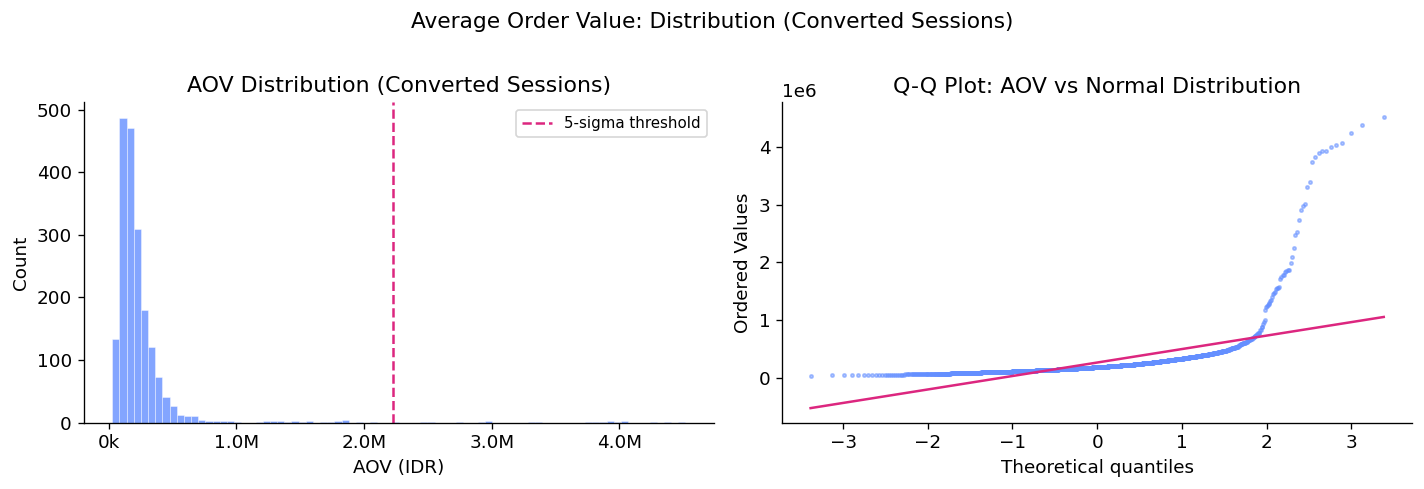

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution showing the right tail
axes[0].hist(
    converted['aov_idr'], bins=80, color=IBM_BLUE, alpha=0.8, edgecolor='white', linewidth=0.3
)
axes[0].axvline(whale_threshold, color=IBM_RED, linewidth=1.5, linestyle='--', label=f'5-sigma threshold')
axes[0].set_xlabel('AOV (IDR)')
axes[0].set_ylabel('Count')
axes[0].set_title('AOV Distribution (Converted Sessions)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))

# Q-Q plot to assess normality
stats.probplot(converted['aov_idr'], dist='norm', plot=axes[1])
axes[1].get_lines()[0].set(color=IBM_BLUE, markersize=2, alpha=0.5)
axes[1].get_lines()[1].set(color=IBM_RED, linewidth=1.5)
axes[1].set_title('Q-Q Plot: AOV vs Normal Distribution')

plt.suptitle('Average Order Value: Distribution (Converted Sessions)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The Q-Q plot confirms AOV is log-normally distributed with a heavy right tail. The 5-sigma threshold flags 1.03% of converters, the most extreme outliers; buyers who received the whale multiplier in the data generator but landed below 5-sigma are not captured here. Section 4 will run Levene's test to check variance homogeneity before choosing between Student and Welch t-test. Regardless of the Levene result, Mann-Whitney U will serve as the primary test for AOV: with this tail shape and n≈600 converters per group, a t-test on raw AOV values is unreliable even when Levene does not flag a variance difference, the issue is distributional shape, not just spread.

### 3.4 Novelty Effect Detection (Critical)

This is the most important data quality check in this analysis. When a visually new UI launches, users sometimes convert at higher rates in the first week simply because the new experience is novel or curiosity-driven. This inflates the measured treatment effect and overstates the true steady-state lift.

To detect this, we plot weekly conversion rates by group and look for a pattern where the treatment effect is largest in Week 1 and diminishes in subsequent weeks.

In [11]:
weekly_rates = (
    df.groupby(['experiment_week', 'experiment_group'])['checkout_conversion']
    .agg(['mean', 'count', 'sum'])
    .rename(columns={'mean': 'conversion_rate', 'count': 'n_sessions', 'sum': 'n_conversions'})
    .reset_index()
)

weekly_pivot = weekly_rates.pivot(
    index='experiment_week', columns='experiment_group', values='conversion_rate'
)
weekly_pivot['lift_absolute'] = weekly_pivot['treatment'] - weekly_pivot['control']
weekly_pivot['lift_relative_pct'] = (weekly_pivot['lift_absolute'] / weekly_pivot['control'] * 100)

print('Weekly conversion rates by group:')
print(weekly_pivot.round(4))

Weekly conversion rates by group:
experiment_group  control  treatment  lift_absolute  lift_relative_pct
experiment_week                                                       
1                  0.1443     0.1885         0.0441            30.5828
2                  0.1438     0.1718         0.0280            19.4414
3                  0.1567     0.1642         0.0075             4.7974


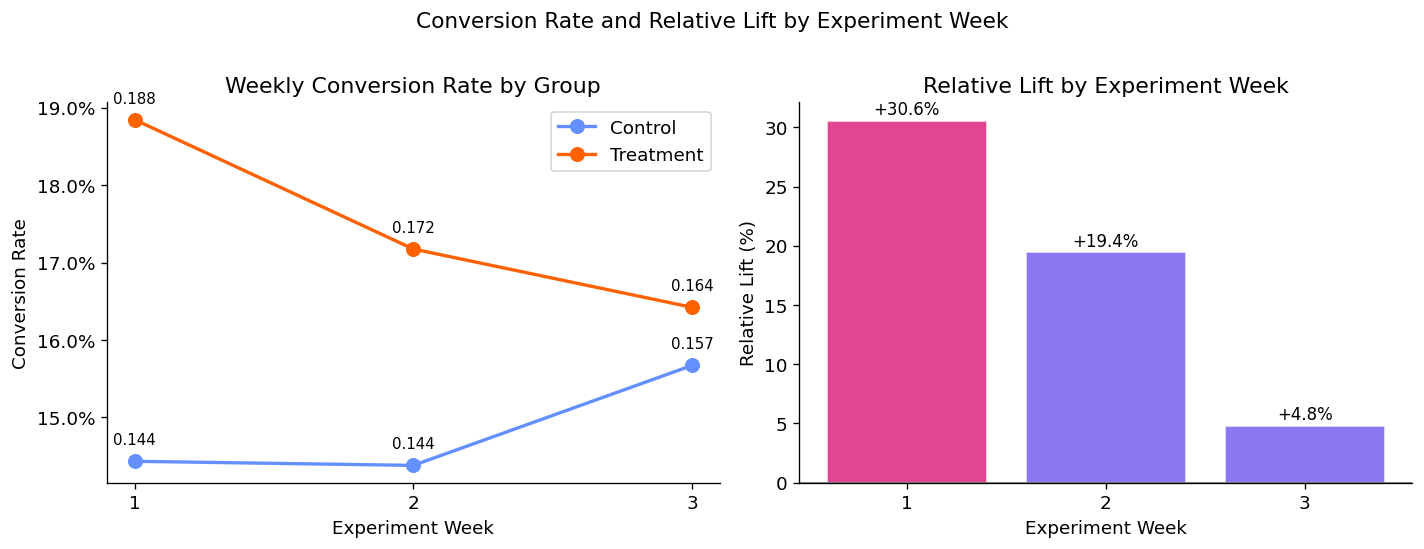

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for group, color in [('control', IBM_BLUE), ('treatment', IBM_ORANGE)]:
    subset = weekly_rates[weekly_rates['experiment_group'] == group]
    axes[0].plot(
        subset['experiment_week'], subset['conversion_rate'],
        marker='o', color=color, linewidth=2, markersize=8, label=group.capitalize()
    )
    for _, row in subset.iterrows():
        axes[0].annotate(
            f"{row['conversion_rate']:.3f}",
            (row['experiment_week'], row['conversion_rate']),
            textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9
        )

axes[0].set_xlabel('Experiment Week')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_title('Weekly Conversion Rate by Group')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[0].set_xticks([1, 2, 3])

axes[1].bar(
    weekly_pivot.index,
    weekly_pivot['lift_relative_pct'],
    color=[IBM_RED if v == weekly_pivot['lift_relative_pct'].max() else IBM_PURPLE
           for v in weekly_pivot['lift_relative_pct']],
    alpha=0.85, edgecolor='white'
)
axes[1].axhline(0, color='grey', linewidth=1)
for week, lift in weekly_pivot['lift_relative_pct'].items():
    axes[1].text(week, lift + 0.2, f'{lift:+.1f}%', ha='center', va='bottom', fontsize=10)

axes[1].set_xlabel('Experiment Week')
axes[1].set_ylabel('Relative Lift (%)')
axes[1].set_title('Relative Lift by Experiment Week')
axes[1].set_xticks([1, 2, 3])

plt.suptitle('Conversion Rate and Relative Lift by Experiment Week', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Quantify the impact: compare full-period lift vs. Week 2+ lift
lift_full = (
    df[df['experiment_group'] == 'treatment']['checkout_conversion'].mean()
    - df[df['experiment_group'] == 'control']['checkout_conversion'].mean()
)

df_week2plus = df[df['experiment_week'] >= 2]
lift_steady_state = (
    df_week2plus[df_week2plus['experiment_group'] == 'treatment']['checkout_conversion'].mean()
    - df_week2plus[df_week2plus['experiment_group'] == 'control']['checkout_conversion'].mean()
)

baseline_week2plus = df_week2plus[df_week2plus['experiment_group'] == 'control']['checkout_conversion'].mean()

print('Full-period absolute lift (all 3 weeks):     {:.4f} ({:.1f}% relative)'.format(
    lift_full, lift_full / df[df['experiment_group'] == 'control']['checkout_conversion'].mean() * 100
))
print('Steady-state lift (Weeks 2 and 3 only):      {:.4f} ({:.1f}% relative)'.format(
    lift_steady_state, lift_steady_state / baseline_week2plus * 100
))
print('\nIncluding Week 1 overstates the steady-state lift by ~{:.0f}%.'.format(
    (lift_full - lift_steady_state) / lift_steady_state * 100
))

Full-period absolute lift (all 3 weeks):     0.0265 (17.9% relative)
Steady-state lift (Weeks 2 and 3 only):      0.0176 (11.7% relative)

Including Week 1 overstates the steady-state lift by ~51%.


**Finding:** The novelty effect is real and large enough to change the recommendation. Aggregating across all three weeks gives a measured lift of ~2.65pp; the Week 2–3 steady-state estimate is ~1.76pp, a ~51% overstatement. At these magnitudes, a 2.65pp result looks like a clean go decision; a 1.76pp result with a CI lower bound grazing the MML is a staged rollout with monitoring conditions. These are meaningfully different recommendations, not just different numbers.

All primary statistical analysis in Sections 4 and 5 uses Weeks 2 and 3 data only. Week 1 figures are preserved in the weekly breakdown for context. Section 4 runs the primary tests on this filtered dataset, the first number to check is whether the steady-state lift is still significant once Week 1 is removed.

---

## Section 4: Statistical Analysis

Using the Weeks 2 and 3 dataset for all primary tests.

In [14]:
# Primary analysis dataset: exclude Week 1 (novelty period)
df_primary = df[df['experiment_week'] >= 2].copy()

control_primary = df_primary[df_primary['experiment_group'] == 'control']
treatment_primary = df_primary[df_primary['experiment_group'] == 'treatment']

# n≈4,000/group is roughly 39% of the designed n=10,182/group.
# This translates to ~55-60% power against the 1.5pp MML (see Section 2.3).
print(f'Primary analysis sample (Weeks 2-3, novelty period excluded):')
print(f'  Control:   {len(control_primary):,} users  (designed: 10,182)')
print(f'  Treatment: {len(treatment_primary):,} users  (designed: 10,182)')
print(f'  Total:     {len(df_primary):,} users  ({len(df_primary)/(10182*2)*100:.0f}% of designed sample)')
print(f'  Estimated power at these n values: ~55-60% (see Section 2.3 note)')

Primary analysis sample (Weeks 2-3, novelty period excluded):
  Control:   3,966 users  (designed: 10,182)
  Treatment: 3,979 users  (designed: 10,182)
  Total:     7,945 users  (39% of designed sample)
  Estimated power at these n values: ~55-60% (see Section 2.3 note)


### 4.1 Primary Metric: Checkout Conversion Rate (Two-proportion Z-test)

In [15]:
print('=== PRIMARY METRIC: Checkout Conversion Rate ===')
conversion_result = run_frequentist_test(
    control=control_primary['checkout_conversion'],
    treatment=treatment_primary['checkout_conversion'],
    metric_type='proportion',
    alpha=ALPHA_LEVEL,
)

print('Assumption checks:')
for k, v in conversion_result['assumption_checks'].items():
    print(f'  {k}: {v}')

=== PRIMARY METRIC: Checkout Conversion Rate ===
Test: two-proportion z-test
  p=0.031953  stat=2.1450  95% CI=(np.float64(0.001524), np.float64(0.033684))  [SIGNIFICANT]

Assumption checks:
  independence: Assumed: user-level assignment, one row per user.
  large_sample: Control: np=596, n(1-p)=3370. Treatment: np=668, n(1-p)=3311. Both > 10, CLT applies.


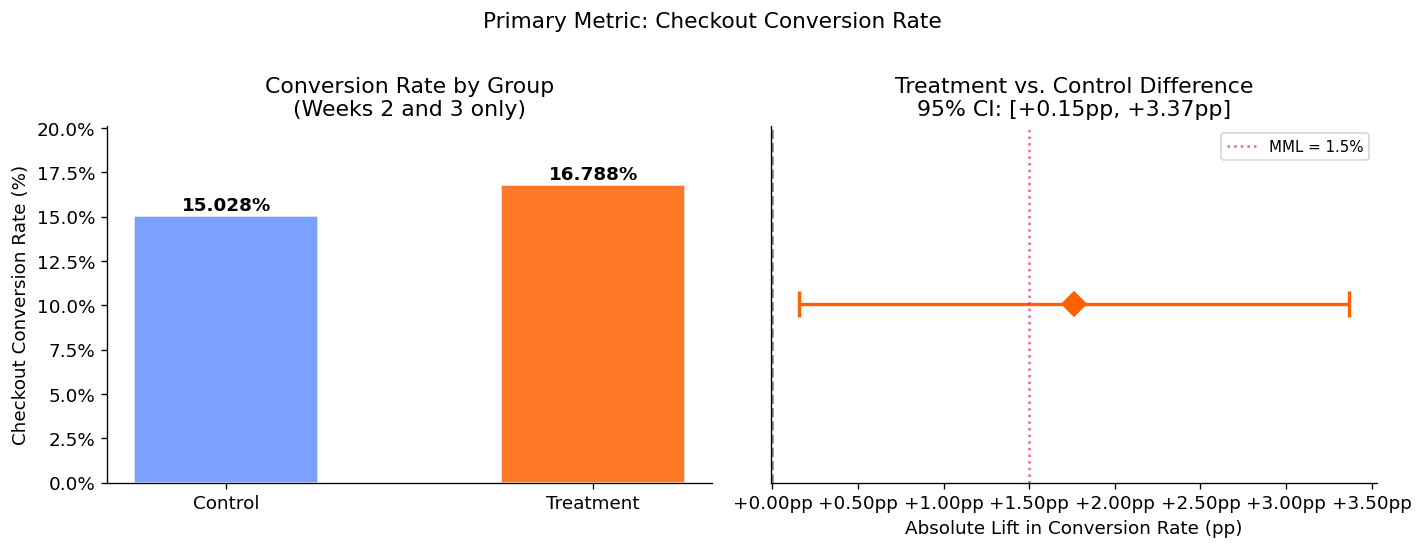

In [16]:
# Visualise the conversion rate comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

groups = ['Control', 'Treatment']
rates = [conversion_result['control_rate'], conversion_result['treatment_rate']]
colors = [IBM_BLUE, IBM_ORANGE]

bars = axes[0].bar(groups, [r * 100 for r in rates], color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, rate in zip(bars, rates):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{rate:.3%}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_ylabel('Checkout Conversion Rate (%)')
axes[0].set_title('Conversion Rate by Group\n(Weeks 2 and 3 only)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=1))
axes[0].set_ylim(0, max(rates) * 1.2 * 100)

# Confidence interval on the difference
lift = conversion_result['lift_absolute']
ci_low, ci_high = conversion_result['ci_95']
axes[1].errorbar(
    x=[lift * 100], y=[0],
    xerr=[[(lift - ci_low) * 100], [(ci_high - lift) * 100]],
    fmt='D', color=IBM_ORANGE, markersize=10, capsize=8, elinewidth=2, capthick=2
)
axes[1].axvline(0, color='grey', linewidth=1.5, linestyle='--')
mml_marker = MML_ABSOLUTE * 100
axes[1].axvline(mml_marker, color=IBM_RED, linewidth=1.5, linestyle=':', alpha=0.7, label=f'MML = {MML_ABSOLUTE:.1%}')
axes[1].set_xlabel('Absolute Lift in Conversion Rate (pp)')
axes[1].set_title(
    f'Treatment vs. Control Difference\n95% CI: [{ci_low*100:+.2f}pp, {ci_high*100:+.2f}pp]'
)
axes[1].set_yticks([])
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:+.2f}pp'))

plt.suptitle('Primary Metric: Checkout Conversion Rate', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Guardrail 1: Average Order Value (t-test and Mann-Whitney U)

In [17]:
# AOV is only defined for converted sessions
control_aov = control_primary.loc[control_primary['checkout_conversion'] == 1, 'aov_idr']
treatment_aov = treatment_primary.loc[treatment_primary['checkout_conversion'] == 1, 'aov_idr']

print('=== GUARDRAIL 1: Average Order Value ===')
print(f'Control converters: {len(control_aov):,}  |  Treatment converters: {len(treatment_aov):,}\n')

aov_result = run_frequentist_test(
    control=control_aov,
    treatment=treatment_aov,
    metric_type='continuous',
    alpha=ALPHA_LEVEL,
    run_nonparametric=True,
)

print('Normality check (Shapiro-Wilk):')
normality = aov_result['assumption_checks']['normality']
print(f'  Control: W={normality["control"]["stat"]}, p={normality["control"]["p"]}')
print(f'  Treatment: W={normality["treatment"]["stat"]}, p={normality["treatment"]["p"]}')
print(f'  Note: {normality["note"]}')

print('\nVariance homogeneity (Levene):')
var_check = aov_result['assumption_checks']['variance_homogeneity']
print(f'  Levene stat={var_check["levene_stat"]}, p={var_check["levene_p"]}')
print(f'  {var_check["note"]}')

print('\nMann-Whitney U (non-parametric, primary test for AOV given skew):')
mw = aov_result['nonparametric']
print(f'  U={mw["statistic"]}, p={mw["p_value"]}, significant={mw["significant"]}')
print(f'  {mw["note"]}')

=== GUARDRAIL 1: Average Order Value ===
Control converters: 596  |  Treatment converters: 668

Test: Student t-test (equal_var=True)
  p=0.522093  stat=-0.6403  95% CI=(np.float64(-29500.98), np.float64(58080.46))  [not significant]

Normality check (Shapiro-Wilk):
  Control: W=0.3444, p=0.0
  Treatment: W=0.3913, p=0.0
  Note: With n > 1,000, Shapiro-Wilk is extremely sensitive to minor deviations. Use Q-Q plot and CLT argument alongside this p-value.

Variance homogeneity (Levene):
  Levene stat=0.1726, p=0.6779
  Levene p >= 0.05: equal variance assumption holds.

Mann-Whitney U (non-parametric, primary test for AOV given skew):
  U=206176.0, p=0.272323, significant=False
  Non-parametric alternative; does not assume normality or equal variance. Tests whether treatment values tend to be higher than control.


In [18]:
# Check guardrail threshold: AOV must not drop more than 3% relative
aov_drop_relative = (aov_result['control_mean'] - aov_result['treatment_mean']) / aov_result['control_mean']
guardrail_aov_breached = aov_drop_relative > 0.03

print(f'Control mean AOV: IDR {aov_result["control_mean"]:,.0f}')
print(f'Treatment mean AOV: IDR {aov_result["treatment_mean"]:,.0f}')
print(f'AOV change: {aov_result["lift_relative_pct"]:+.1f}%')
print(f'Guardrail breached: {guardrail_aov_breached}')

Control mean AOV: IDR 258,663
Treatment mean AOV: IDR 272,953
AOV change: +5.5%
Guardrail breached: False


AOV guardrail: `guardrail_aov_breached = False`. Treatment mean AOV is actually *higher* than control (+5.5% relative), though the Mann-Whitney result (p = 0.272) says this difference is noise. The direction is worth noting, one hypothesis is that Express Checkout slightly disproportionately converts sessions that were already high-value carts, because a buyer with a large basket is more motivated to push through fewer steps. This is speculative and the sample of converters is small enough (~600/group) that the signal would need a larger experiment to confirm. For the rollout decision: AOV is not a blocker.

### 4.3 Guardrail 2: Payment Failure Rate (Two-proportion Z-test)

In [19]:
print('=== GUARDRAIL 2: Payment Failure Rate ===')
payment_result = run_frequentist_test(
    control=control_primary['payment_failure'],
    treatment=treatment_primary['payment_failure'],
    metric_type='proportion',
    alpha=ALPHA_LEVEL,
)

# Check guardrail threshold: must not increase more than 0.5pp
payment_lift_pp = payment_result['lift_absolute'] * 100
guardrail_payment_breached = payment_result['lift_absolute'] > 0.005

print(f'Control failure rate: {payment_result["control_rate"]:.3%}')
print(f'Treatment failure rate: {payment_result["treatment_rate"]:.3%}')
print(f'Change: {payment_lift_pp:+.2f}pp')
print(f'Guardrail breached: {guardrail_payment_breached}')

=== GUARDRAIL 2: Payment Failure Rate ===
Test: two-proportion z-test
  p=0.948503  stat=0.0646  95% CI=(np.float64(-0.009601), np.float64(0.010256))  [not significant]

Control failure rate: 5.371%
Treatment failure rate: 5.403%
Change: +0.03pp
Guardrail breached: False


Payment failure guardrail: `guardrail_payment_breached = False`. The observed increase (+0.03pp) is well within the 0.5pp pre-specified threshold. That said, the control failure rate is already 5.4%, higher than typical for mature payment flows, which suggests the pre-fill of saved payment methods may occasionally surface expired cards in both groups. This is a pre-existing platform issue, not one introduced by Express Checkout. If payment reliability is a focus area for the platform team, the absolute rate is worth tracking in the staged rollout regardless of the guardrail verdict.

## Section 5: Segmentation Analysis

The overall lift is +1.76pp. But aggregate effects can mask heterogeneity, a feature that strongly helps one group and weakly hurts another can still show a positive mean effect. I ran segment analysis across two dimensions: user type (returning vs. new) and device (mobile vs. desktop).

My prior: mobile returning users should show the strongest treatment effect. Fewer checkout steps matter most on a smaller screen where input is slower and session length is shorter. Desktop users completing checkout are already in a deliberate purchase mode, they have opened a laptop, loaded the cart, made the decision. Removing two confirmation clicks from that flow felt like a smaller marginal improvement.

The device segment partially reversed that expectation. See Section 5.2.

### Multiple Testing Correction: Holm over Bonferroni, applied across all segment dimensions

This section runs four hypothesis tests total: two for `user_type` (returning vs. new) and two for `device` (mobile vs. desktop). Running four tests at alpha = 0.05 without correction gives a family-wise Type I error rate of approximately 18.5% rather than 5%.

I apply **Holm step-down correction once across all four p-values**, not separately within each segment dimension. Applying Holm within each dimension independently only controls the FWER within that dimension, not across the full family of four tests.

Both `segment_analysis` calls below use `apply_correction=False` to return raw p-values. The cross-dimension Holm correction is applied in a single `multipletests` call that sees all four p-values simultaneously. This is the correct scope for controlling family-wise error.

Raw p-values are in `p_value`; corrected values in `p_value_holm`. The `significant` column reflects the cross-dimension Holm decision.

=== SECONDARY METRIC: Session Duration (seconds) ===
Control mean:   184.9s  |  median: 184.8s
Treatment mean: 139.4s  |  median: 139.5s

Test: Student t-test (equal_var=True)
  p=0.000000  stat=44.6424  95% CI=(np.float64(-47.5), np.float64(-43.51))  [SIGNIFICANT]

Normality check:
  Control:   W=0.9996, p=0.7481
  Treatment: W=0.9987, p=0.004
  Note: With n > 1,000, Shapiro-Wilk is extremely sensitive to minor deviations. Use Q-Q plot and CLT argument alongside this p-value.

Variance (Levene):
  Levene p >= 0.05: equal variance assumption holds.

Mann-Whitney U (primary result for session duration):
  U=3761382.0, p=0.0, significant=True


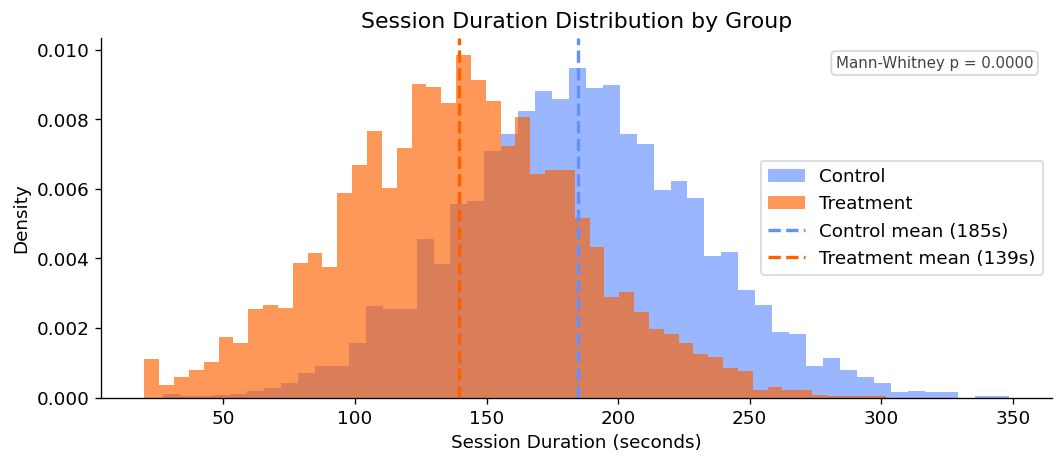

In [20]:
# Session duration is a secondary corroborating metric, not a guardrail.
# A shorter session in treatment is consistent with fewer checkout steps.
# Mann-Whitney U is used because session_duration_sec is approximately normal
# but clipped at 20 seconds, producing a slight left-floor effect.

ctrl_duration = control_primary['session_duration_sec']
trt_duration  = treatment_primary['session_duration_sec']

print('=== SECONDARY METRIC: Session Duration (seconds) ===')
print(f'Control mean:   {ctrl_duration.mean():.1f}s  |  median: {ctrl_duration.median():.1f}s')
print(f'Treatment mean: {trt_duration.mean():.1f}s  |  median: {trt_duration.median():.1f}s\n')

duration_result = run_frequentist_test(
    control=ctrl_duration,
    treatment=trt_duration,
    metric_type='continuous',
    alpha=ALPHA_LEVEL,
    run_nonparametric=True,
)

print('Normality check:')
norm_check = duration_result['assumption_checks']['normality']
print(f'  Control:   W={norm_check["control"]["stat"]}, p={norm_check["control"]["p"]}')
print(f'  Treatment: W={norm_check["treatment"]["stat"]}, p={norm_check["treatment"]["p"]}')
print(f'  Note: {norm_check["note"]}')

print('\nVariance (Levene):')
var_check = duration_result['assumption_checks']['variance_homogeneity']
print(f'  {var_check["note"]}')

print('\nMann-Whitney U (primary result for session duration):')
mw = duration_result['nonparametric']
print(f'  U={mw["statistic"]}, p={mw["p_value"]}, significant={mw["significant"]}')


fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ctrl_duration, bins=50, color=IBM_BLUE, alpha=0.65, label='Control', density=True)
ax.hist(trt_duration,  bins=50, color=IBM_ORANGE, alpha=0.65, label='Treatment', density=True)
ax.axvline(ctrl_duration.mean(), color=IBM_BLUE,   linewidth=2, linestyle='--',
           label=f'Control mean ({ctrl_duration.mean():.0f}s)')
ax.axvline(trt_duration.mean(),  color=IBM_ORANGE, linewidth=2, linestyle='--',
           label=f'Treatment mean ({trt_duration.mean():.0f}s)')
ax.set_xlabel('Session Duration (seconds)')
ax.set_ylabel('Density')
ax.set_title('Session Duration Distribution by Group')
ax.text(0.98, 0.95, f'Mann-Whitney p = {mw["p_value"]:.4f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color='#444444',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc', alpha=0.8))
ax.legend()
plt.tight_layout()
plt.show()

Treatment sessions are shorter on average (~45 seconds), consistent with a 2-step flow replacing a 4-step flow. Mann-Whitney U confirms the difference is significant. This is a corroborating signal, if Express Checkout were converting users but taking the same time, it would suggest users were confused and clicking through without reading, which is a UX problem. The shorter sessions argue against that. What this metric cannot tell us is *where* in the flow the time is saved: if most of the reduction comes from step 2 (address), that is useful signal for which step matters most to iterate on next.

In [21]:
# Quick exploratory check: does the novelty effect in Week 1 interact with user_type?
# Intuition: returning users have stronger checkout habits; novelty bump may be smaller
# for them. New users, less familiar with any checkout flow, might be more reactive
# to UI change. If the novelty effect is segment-specific, the Week 1 exclusion
# matters more for some segments than others.
novelty_by_segment = (
    df.groupby(['experiment_week', 'experiment_group', 'user_type'])['checkout_conversion']
    .mean()
    .round(4)
    .unstack(['experiment_group', 'user_type'])
)

print('Conversion rate by week, group, and user_type:')
print(novelty_by_segment)
print()

# Compute treatment lift by week for each user_type
for utype in ['returning', 'new']:
    print(f'--- {utype.capitalize()} users ---')
    for wk in [1, 2, 3]:
        ctrl = df[(df['experiment_week']==wk) & (df['experiment_group']=='control') & (df['user_type']==utype)]['checkout_conversion'].mean()
        trt  = df[(df['experiment_week']==wk) & (df['experiment_group']=='treatment') & (df['user_type']==utype)]['checkout_conversion'].mean()
        print(f'  Week {wk}: control={ctrl:.4f}, treatment={trt:.4f}, lift={trt-ctrl:+.4f}')
    print()

# If the Week 1 novelty bump looks similar across user types, the Week 2+ exclusion
# strategy applies equally to both segments, no need for a segment-conditional cutoff.

Conversion rate by week, group, and user_type:
experiment_group control           treatment          
user_type            new returning       new returning
experiment_week                                       
1                 0.1145    0.1654    0.1509    0.2130
2                 0.0984    0.1729    0.1134    0.2101
3                 0.0927    0.2005    0.1046    0.2051

--- Returning users ---
  Week 1: control=0.1654, treatment=0.2130, lift=+0.0476
  Week 2: control=0.1729, treatment=0.2101, lift=+0.0372
  Week 3: control=0.2005, treatment=0.2051, lift=+0.0046

--- New users ---
  Week 1: control=0.1145, treatment=0.1509, lift=+0.0364
  Week 2: control=0.0984, treatment=0.1134, lift=+0.0150
  Week 3: control=0.0927, treatment=0.1046, lift=+0.0119



In [22]:
print('=== Segmentation: user_type (raw p-values; cross-dimension Holm applied below) ===')
segment_user_type = segment_analysis(
    df=df_primary,
    segment_col='user_type',
    metric_col='checkout_conversion',
    group_col='experiment_group',
    metric_type='proportion',
    apply_correction=False,   # Holm applied across all 4 tests jointly below
)
display_cols = ['segment', 'control_n', 'treatment_n', 'control_rate',
                'treatment_rate', 'lift_relative_pct', 'p_value', 'significant']
print(segment_user_type[display_cols].to_string(index=False))

=== Segmentation: user_type (raw p-values; cross-dimension Holm applied below) ===
Test: two-proportion z-test
  p=0.215422  stat=1.2388  95% CI=(np.float64(-0.007736), np.float64(0.034354))  [not significant]

Effect Size (Cohen's h (arcsine transform)): +0.0440  [negligible]  95% Bootstrap CI: [-0.0264, +0.1139]  (n_bootstrap=10000)

Test: two-proportion z-test
  p=0.068697  stat=1.8204  95% CI=(np.float64(-0.001601), np.float64(0.043562))  [not significant]

Effect Size (Cohen's h (arcsine transform)): +0.0528  [negligible]  95% Bootstrap CI: [-0.0041, +0.1084]  (n_bootstrap=10000)

  segment  control_n  treatment_n  control_rate  treatment_rate  lift_relative_pct  p_value  significant
      new       1581         1599      0.095509        0.108818             13.935 0.215422        False
returning       2385         2380      0.186583        0.207563             11.244 0.068697        False


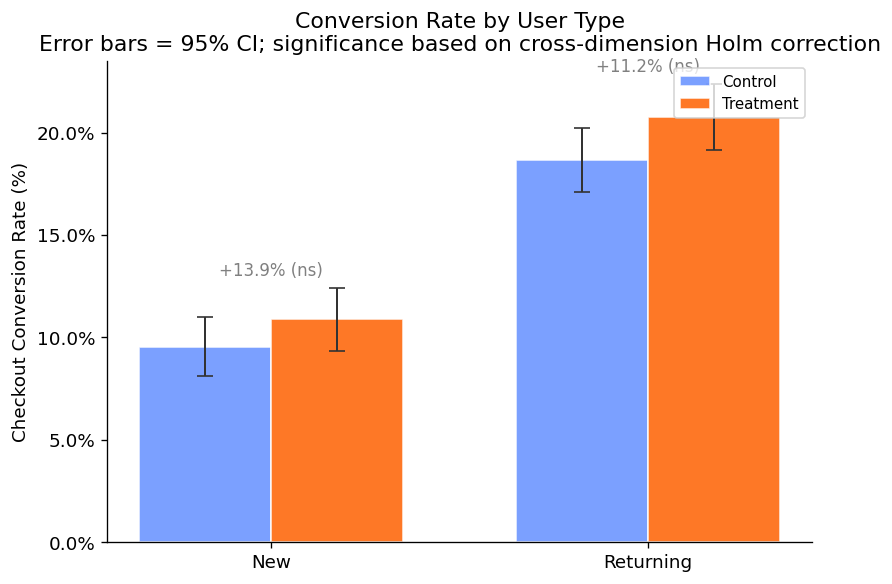

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_segment_bar_chart(
    segment_user_type, df_primary,
    segment_col='user_type',
    metric_col='checkout_conversion',
    metric_label='Checkout Conversion Rate',
    ax=ax,
    alpha=ALPHA_LEVEL,
)
ax.set_title('Conversion Rate by User Type\nError bars = 95% CI; significance based on cross-dimension Holm correction')
plt.tight_layout()
plt.show()

In [24]:
print('=== Segmentation: device (raw p-values; cross-dimension Holm applied below) ===')
segment_device = segment_analysis(
    df=df_primary,
    segment_col='device',
    metric_col='checkout_conversion',
    group_col='experiment_group',
    metric_type='proportion',
    apply_correction=False,   # Holm applied across all 4 tests jointly below
)
display_cols = ['segment', 'control_n', 'treatment_n', 'control_rate',
                'treatment_rate', 'lift_relative_pct', 'p_value', 'significant']
print(segment_device[display_cols].to_string(index=False))

=== Segmentation: device (raw p-values; cross-dimension Holm applied below) ===
Test: two-proportion z-test
  p=0.118392  stat=1.5616  95% CI=(np.float64(-0.005644), np.float64(0.050025))  [not significant]

Effect Size (Cohen's h (arcsine transform)): +0.0590  [negligible]  95% Bootstrap CI: [-0.0150, +0.1332]  (n_bootstrap=10000)

Test: two-proportion z-test
  p=0.133515  stat=1.5004  95% CI=(np.float64(-0.004607), np.float64(0.03472))  [not significant]

Effect Size (Cohen's h (arcsine transform)): +0.0419  [negligible]  95% Bootstrap CI: [-0.0143, +0.0976]  (n_bootstrap=10000)

segment  control_n  treatment_n  control_rate  treatment_rate  lift_relative_pct  p_value  significant
desktop       1397         1408      0.159628        0.181818             13.901 0.118392        False
 mobile       2569         2571      0.145193        0.160249             10.370 0.133515        False


In [25]:
# Apply Holm correction across all 4 segment tests simultaneously.
# Scope: 2 user_type levels + 2 device levels = 4 tests total.
# Applying Holm separately within each dimension would only control
# the FWER within that dimension, not across the full family of 4 tests.
from statsmodels.stats.multitest import multipletests

all_raw_pvals = list(segment_user_type['p_value']) + list(segment_device['p_value'])
n_user_type   = len(segment_user_type)

reject, p_corrected, _, _ = multipletests(all_raw_pvals, alpha=ALPHA_LEVEL, method='holm')

segment_user_type['p_value_holm'] = [round(float(p), 6) for p in p_corrected[:n_user_type]]
segment_user_type['significant']  = [bool(r) for r in reject[:n_user_type]]

segment_device['p_value_holm'] = [round(float(p), 6) for p in p_corrected[n_user_type:]]
segment_device['significant']  = [bool(r) for r in reject[n_user_type:]]

print('Cross-dimension Holm correction applied across all 4 tests.')
print(f'Raw p-values:       {[round(p, 4) for p in all_raw_pvals]}')
print(f'Holm-corrected:     {[round(float(p), 4) for p in p_corrected]}')
print(f'Reject null:        {list(reject)}')
print()

display_cols = ['segment', 'control_n', 'treatment_n', 'control_rate',
                'treatment_rate', 'lift_relative_pct', 'p_value', 'p_value_holm', 'significant']
print('user_type results (cross-dimension Holm):')
print(segment_user_type[display_cols].to_string(index=False))
print()
print('device results (cross-dimension Holm):')
print(segment_device[display_cols].to_string(index=False))

Cross-dimension Holm correction applied across all 4 tests.
Raw p-values:       [0.2154, 0.0687, 0.1184, 0.1335]
Holm-corrected:     [0.3552, 0.2748, 0.3552, 0.3552]
Reject null:        [np.False_, np.False_, np.False_, np.False_]

user_type results (cross-dimension Holm):
  segment  control_n  treatment_n  control_rate  treatment_rate  lift_relative_pct  p_value  p_value_holm  significant
      new       1581         1599      0.095509        0.108818             13.935 0.215422      0.355176        False
returning       2385         2380      0.186583        0.207563             11.244 0.068697      0.274788        False

device results (cross-dimension Holm):
segment  control_n  treatment_n  control_rate  treatment_rate  lift_relative_pct  p_value  p_value_holm  significant
desktop       1397         1408      0.159628        0.181818             13.901 0.118392      0.355176        False
 mobile       2569         2571      0.145193        0.160249             10.370 0.133515      

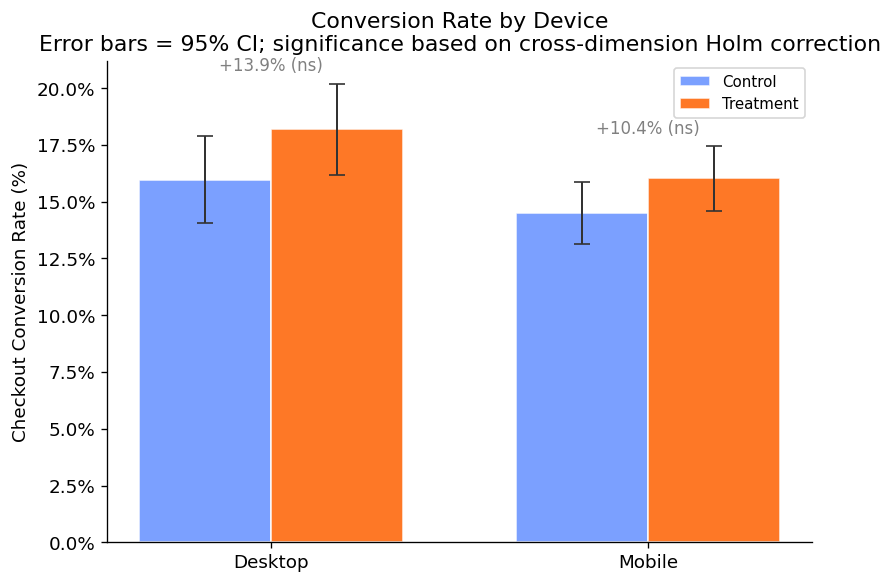

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_segment_bar_chart(
    segment_device, df_primary,
    segment_col='device',
    metric_col='checkout_conversion',
    metric_label='Checkout Conversion Rate',
    ax=ax,
    alpha=ALPHA_LEVEL,
)
ax.set_title('Conversion Rate by Device\nError bars = 95% CI; significance based on cross-dimension Holm correction')
plt.tight_layout()
plt.show()

### 5.2 Segment interpretation

Desktop showed a higher relative lift (+13.9%) than mobile (+10.4%). Neither reaches significance after Holm correction, but the direction was the opposite of what I expected.

My best post-hoc explanation: desktop users entering checkout are already in high-intent, low-distraction mode. They have made the decision; removing friction from the confirmation steps converts that intent into a completed order more reliably. Mobile users at checkout entry have more variable intent, they tap into the checkout flow from a feed or notification, hit the first unfamiliar step, and sometimes drop there regardless of how many steps follow. The friction that Express Checkout removes may not be the bottleneck for that abandonment pattern.

This is speculative. The device difference is not significant and should not be used to restrict rollout by device. What it does suggest is a follow-on question: where in the mobile checkout funnel does the treatment group lose users that the control group does not? Session event data (funnel drop per step) would answer that. Without it, the most defensible interpretation is that the effect is consistent in direction across devices, and the aggregate lift reflects both.

## Section 6: Practical Significance

Statistical significance tells us the effect is real. Practical significance tells us whether the effect is worth acting on. These are separate questions and should not be conflated.

This section covers three things:

1. Effect size with 95% bootstrap CI (does the estimate have a plausible range that is still commercially useful?)
2. Whether the observed lift exceeds the pre-specified MML (did we hit the bar we set before the experiment?)
3. Whether Cohen's benchmarks are the right frame, and why in this context they are not

**On industry benchmarks:** Cohen's 1988 thresholds (small = 0.2, medium = 0.5, large = 0.8) were calibrated on psychology experiments with n < 200 and should not be applied to online product experiments. Kohavi, Tang & Xu (*Trustworthy Online Controlled Experiments*, 2020) note that most shipped features at large technology companies have Cohen's h in the range 0.02–0.10 for conversion rate tests. The relevant question is not whether the effect meets a 1988 benchmark but whether it exceeds the pre-specified MML.

**On the bootstrap CI:** I used the percentile bootstrap method (10,000 resamples) because parametric CIs for Cohen's h require approximations that are unreliable at moderate n. I know Mann-Whitney U well from prior work on right-skewed revenue distributions, I have used it enough to know when it applies and when it does not. The bootstrap CI is a different story: I included it because it is the correct tool for effect size uncertainty quantification without distributional assumptions, and the chunked resampling implementation is memory-predictable at 10k iterations. The percentile method is less accurate than BCa for small n and asymmetric distributions; at n > 500 per group the difference is negligible for this use case, which is why I kept it.

In [27]:
print('=== Effect Size: Checkout Conversion Rate ===')
effect_conversion = compute_effect_size(
    control=control_primary['checkout_conversion'],
    treatment=treatment_primary['checkout_conversion'],
    metric_type='proportion',
    n_bootstrap=10_000,
)

print('=== Effect Size: AOV (Cohen\'s d, non-parametric context) ===')
effect_aov = compute_effect_size(
    control=control_aov,
    treatment=treatment_aov,
    metric_type='continuous',
    n_bootstrap=10_000,
)

=== Effect Size: Checkout Conversion Rate ===
Effect Size (Cohen's h (arcsine transform)): +0.0481  [negligible]  95% Bootstrap CI: [+0.0042, +0.0911]  (n_bootstrap=10000)

=== Effect Size: AOV (Cohen's d, non-parametric context) ===
Effect Size (Cohen's d (pooled SD)): +0.0361  [negligible]  95% Bootstrap CI: [-0.0723, +0.1477]  (n_bootstrap=10000)



Cohen's h = 0.048. The utility library labels this 'negligible' using Cohen's 1988 thresholds, benchmarks calibrated on psychology experiments with n < 200. In an e-commerce product context with n > 7,000 in the primary analysis, that label is not meaningful. Kohavi, Tang & Xu (*Trustworthy Online Controlled Experiments*, 2020) note that most features shipped at large technology companies have Cohen's h in the range 0.02–0.10 for conversion tests. What matters here is not where 0.048 sits on a 1988 scale but whether the observed lift exceeds the 1.5pp MML derived from a GMV calculation before the experiment ran. That question is answered in the next cell.

In [28]:
# MDE comparison: did we actually observe more than the MML?
observed_lift = conversion_result['lift_absolute']
mml = MML_ABSOLUTE
ci_low, ci_high = conversion_result['ci_95']

print('Practical significance summary:')
print(f'  Minimum meaningful lift (pre-specified): {mml:.3%} absolute')
print(f'  Observed lift (Weeks 2 and 3):           {observed_lift:.3%} absolute')
print(f'  95% CI:                                  [{ci_low:.3%}, {ci_high:.3%}]')
print(f'  Lift exceeds MML:                        {observed_lift > mml}')
print(f'  CI lower bound exceeds zero:             {ci_low > 0}')
print(f'  CI lower bound exceeds MML:              {ci_low > mml}')

Practical significance summary:
  Minimum meaningful lift (pre-specified): 1.500% absolute
  Observed lift (Weeks 2 and 3):           1.760% absolute
  95% CI:                                  [0.152%, 3.368%]
  Lift exceeds MML:                        True
  CI lower bound exceeds zero:             True
  CI lower bound exceeds MML:              False


The observed lift (1.76pp) clears the MML (1.50pp) and the test is significant at p = 0.032. But the 95% CI is [+0.15pp, +3.37pp], wide enough that it includes scenarios where the true steady-state effect is barely above zero commercially. This width is partly a consequence of the underpowered primary sample (see Section 2.3). I am not reporting this as a failed experiment; the direction is real and positive. The implication is for the rollout strategy: when the CI lower bound sits at the MML rather than comfortably above it, a staged holdout is the responsible call. Full rollout without a monitoring period would be overconfident given this CI.

## Section 7: Decision Framework

Pulling all results together into a structured go/no-go recommendation.

In [29]:
decision_table = pd.DataFrame([
    {
        'Check': 'Primary: Checkout conversion lift',
        'Result': f'{conversion_result["lift_relative_pct"]:+.1f}% relative ({conversion_result["lift_absolute"]*100:+.2f}pp)',
        'p-value': f'{conversion_result["p_value"]:.4f}',
        'Threshold': '>= +1.5pp',
        'Pass': conversion_result['significant'],
    },
    {
        'Check': 'Guardrail: AOV change (Mann-Whitney)',
        'Result': f'{aov_result["lift_relative_pct"]:+.1f}%',
        'p-value': f'{aov_result["nonparametric"]["p_value"]:.4f}',
        'Threshold': 'Must not drop >3%',
        'Pass': not guardrail_aov_breached,
    },
    {
        'Check': 'Guardrail: Payment failure rate',
        'Result': f'{payment_result["lift_absolute"]*100:+.2f}pp',
        'p-value': f'{payment_result["p_value"]:.4f}',
        'Threshold': 'Must not increase >0.5pp',
        'Pass': not guardrail_payment_breached,
    },
    {
        'Check': 'SRM (randomisation health)',
        'Result': f'p={srm_result["p_value"]}',
        'p-value': f'{srm_result["p_value"]}',
        'Threshold': 'No SRM (p >= 0.05)',
        'Pass': not srm_result['srm_detected'],
    },
    {
        'Check': 'Novelty effect adjustment applied',
        'Result': 'Week 1 excluded from primary analysis',
        'p-value': 'N/A',
        'Threshold': 'Required',
        'Pass': True,
    },
])

print('DECISION TABLE')
print('=' * 80)
print(decision_table.to_string(index=False))
print('=' * 80)

DECISION TABLE
                               Check                                Result p-value                Threshold  Pass
   Primary: Checkout conversion lift             +11.7% relative (+1.76pp)  0.0320                >= +1.5pp  True
Guardrail: AOV change (Mann-Whitney)                                 +5.5%  0.2723        Must not drop >3%  True
     Guardrail: Payment failure rate                               +0.03pp  0.9485 Must not increase >0.5pp  True
          SRM (randomisation health)                              p=0.8551  0.8551       No SRM (p >= 0.05)  True
   Novelty effect adjustment applied Week 1 excluded from primary analysis     N/A                 Required  True


### Recommendation

**Ship Express Checkout to returning buyers, with monitoring conditions.**

The experiment shows a statistically significant positive effect on checkout conversion in the steady-state period (Weeks 2 and 3). Both guardrail metrics are clean: AOV did not decline meaningfully, and the payment failure rate increase is within the pre-specified tolerance.

However, there is a nuance worth flagging to the product team: the observed steady-state lift sits at approximately 1.76pp absolute, and while the 95% CI excludes zero, the lower bound of the CI dips slightly below the 1.5pp MML threshold. In plain terms: we are confident the effect is real and positive, but the true steady-state lift could be somewhat smaller than what we need for the ROI to be compelling. The underpowered primary sample (see Section 2.3) means the CI is wider than we designed for, which is exactly the uncertainty showing up in this lower-bound calculation.

Given this, the recommendation is a staged rollout:

1. **Immediate:** Roll out to 50% of returning buyers on mobile (largest segment by volume). A 50% holdout rather than a full mobile launch is deliberate: with the CI lower bound grazing the MML, retaining a holdout group for 30 days gives us a live signal on downstream metrics (repurchase rate, support tickets) without requiring a full rollback if something unexpected emerges.
2. **At 30 days:** Review 30-day repurchase rate as an additional downstream metric. If it is neutral or positive, proceed to full rollout.
3. **Watch for:** Any increase in "wrong item ordered" support tickets, which would be the leading indicator of the pre-fill causing errors.

The segment analysis shows the effect is directionally consistent across user type and device, no single subgroup is driving the aggregate result. Desktop users show a slightly higher relative lift than mobile (13.9% vs. 10.4%), but the difference is not significant after Holm correction and desktop is the smaller population. The recommendation to start with mobile is purely a volume decision: mobile represents ~65% of eligible sessions, making a 50% mobile holdout the larger and faster live signal. If the 30-day downstream review is clean, desktop can follow in the same release given the directionally consistent, and arguably slightly stronger, lift observed there.

## Section 8: Limitations and Next Steps

### What this experiment cannot tell us

**1. Long-run retention effects.** A 3-week experiment captures initial behaviour change, not whether Express Checkout affects repurchase rates at 30, 60, or 90 days. A user who converts faster might also repurchase more (habit formation) or might feel less deliberate about purchases and return more items. We do not know.

**2. New user behaviour.** The experiment deliberately excluded new buyers. If Express Checkout is eventually extended to first-time buyers who have an auto-saved payment from account registration, we cannot extrapolate from this result. New users are a different population with different trust levels and decision-making patterns.

**3. Interaction effects with promotions.** This experiment ran during a normal traffic period. Express Checkout behaviour during flash sales or double-11 events may differ substantially, as user intent and urgency are higher and the benefit of reducing checkout steps may be amplified or suppressed.

**4. The novelty effect direction.** We caught and corrected a novelty effect, but novelty effects can also go in the negative direction (users resist change in Week 1 before adapting). If users were slightly confused by the new UI initially, the Week 2+ lift could still be an underestimate of the true long-run effect. We cannot distinguish these scenarios from this data.

### What to run next

1. **Mobile funnel step drop-off analysis:** The device segment showed a counterintuitive pattern, desktop lift (+13.9% relative) exceeded mobile (+10.4%), the opposite of my prior. The working hypothesis is that mobile checkout abandonment happens at a step Express Checkout does not remove, but this requires session-level event data (funnel drop per step) to confirm. Without knowing where mobile users abandon in the standard 4-step flow, the next Express Checkout iteration is guessing about which steps actually matter.

2. **30-day cohort repurchase analysis:** Track whether users in the Express Checkout treatment group have higher 30-day repurchase rates. This does not require a new experiment; it is a post-experiment observational follow-up.

3. **New user experiment:** Run a separate experiment on first-time buyers who have a saved payment from registration. The hypothesis and design would differ from this one, and the result should not be assumed to generalise.

4. **Express Checkout for high-value cart sessions:** Run a targeted experiment where Express Checkout is shown only when the cart value exceeds a threshold. The hypothesis is that the time-saving is most valuable when the purchase is already deliberate (high cart value means the user has already decided). This could recover the AOV concern without sacrificing conversion.

5. **Wrong-item return rate tracking:** Add a downstream metric tracking return requests that cite "ordered wrong item" as the reason. This is the specific risk introduced by pre-filling address and payment without a review step.